In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('Datasets/sales_train.csv')

In [3]:
calendar = pd.read_csv('Datasets/calendar.csv')

In [4]:
inventory = pd.read_csv('Datasets/inventory.csv')


In [5]:
test_weight = pd.read_csv(r'Datasets/test_weights.csv')


Lets us apply feature engineering in sales-train

In [6]:
data

,unique_id,date,warehouse,total_orders,sales,sell_price_main,availability,type_0_discount,type_1_discount,type_2_discount,type_3_discount,type_4_discount,type_5_discount,type_6_discount
0,4845,2024-03-10,Budapest_1,6436.0,16.34,646.26,1.00,0.00000,0.0,0.0,0.0,0.15312,0.0,0.0
1,4845,2021-05-25,Budapest_1,4663.0,12.63,455.96,1.00,0.00000,0.0,0.0,0.0,0.15025,0.0,0.0
2,4845,2021-12-20,Budapest_1,6507.0,34.55,455.96,1.00,0.00000,0.0,0.0,0.0,0.15025,0.0,0.0
3,4845,2023-04-29,Budapest_1,5463.0,34.52,646.26,0.96,0.20024,0.0,0.0,0.0,0.15312,0.0,0.0
4,4845,2022-04-01,Budapest_1,5997.0,35.92,486.41,1.00,0.00000,0.0,0.0,0.0,0.15649,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4007414,4941,2023-06-21,Prague_1,9988.0,26.56,34.06,1.00,0.00000,0.0,0.0,0.0,0.00000,0.0,0.0
4007415,4941,2023-06-24,Prague_1,8518.0,27.42,34.06,1.00,0.00000,0.0,0.0,0.0,0.00000,0.0,0.0
4007416,4941,2023-06-23,Prague_1,10424.0,33.39,34.06,1.00,0.00000,0.0,0.0,0.0,0.00000,0.0,0.0
4007417,4941,2023-06-22,Prague_1,10342.0,22.88,34.06,1.00,0.00000,0.0,0.0,0.0,0.00000,0.0,0.0


In [7]:
data['warehouse'].unique()

array(['Budapest_1', 'Prague_2', 'Brno_1', 'Prague_1', 'Prague_3',
       'Munich_1', 'Frankfurt_1'], dtype=object)

In [8]:
data.isnull().sum()

unique_id           0
date                0
warehouse           0
total_orders       52
sales              52
sell_price_main     0
availability        0
type_0_discount     0
type_1_discount     0
type_2_discount     0
type_3_discount     0
type_4_discount     0
type_5_discount     0
type_6_discount     0
dtype: int64

In [9]:
data['total_orders'].isnull().sum()

52

Visualization in sales_train

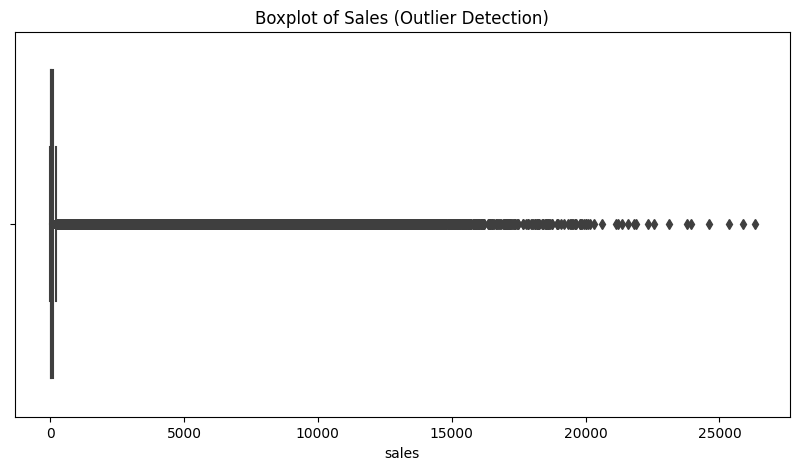

In [10]:
#Box plot 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(x=data['sales'])
plt.title("Boxplot of Sales (Outlier Detection)")
plt.show()


In [11]:
"""import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()
"""

'import seaborn as sns\nimport matplotlib.pyplot as plt\n\nplt.figure(figsize=(10,6))\nsns.heatmap(data.corr(), annot=True, cmap="coolwarm", linewidths=0.5)\nplt.title("Feature Correlation Heatmap")\nplt.show()\n'

c:\Users\Musta\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


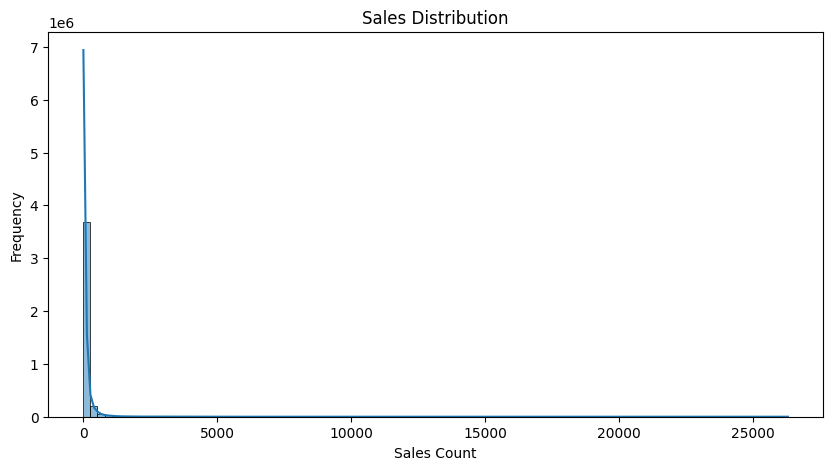

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(data['sales'], bins=100, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales Count")
plt.ylabel("Frequency")
plt.show()


In [13]:
skewness = data['sales'].skew()
skewness

22.36323642023012

In [14]:
# Define the clipping range
lower_bound = data['sales'].quantile(0.05)
upper_bound = data['sales'].quantile(0.95)

# Clip the sales data
data['sales'] = data['sales'].clip(lower=lower_bound, upper=upper_bound)

# Check the skewness after clipping
data['sales'] = data['sales'].skew()


c:\Users\Musta\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


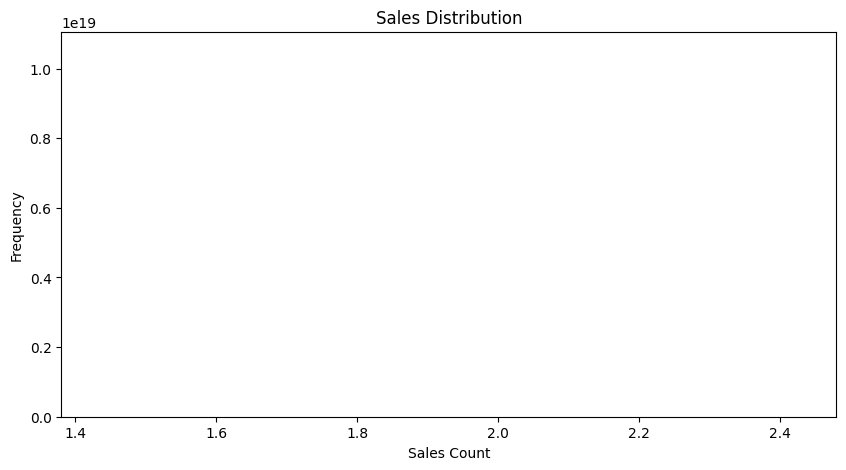

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(data['sales'], bins=100, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales Count")
plt.ylabel("Frequency")
plt.show()


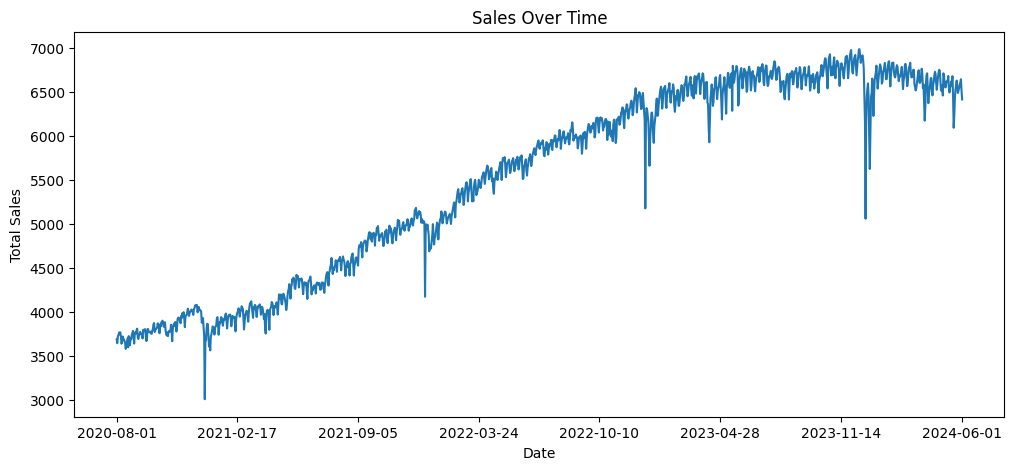

In [16]:
plt.figure(figsize=(12,5))
data.groupby('date')['sales'].sum().plot(kind='line')
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()


In [17]:
"""plt.figure(figsize=(12,5))
sns.boxplot(x='unique_id', y='sales', data=data)
plt.title("Sales Distribution per Store")
plt.xticks(rotation=90)
plt.show()
"""

'plt.figure(figsize=(12,5))\nsns.boxplot(x=\'unique_id\', y=\'sales\', data=data)\nplt.title("Sales Distribution per Store")\nplt.xticks(rotation=90)\nplt.show()\n'

In [18]:
data.isnull().sum()

unique_id           0
date                0
warehouse           0
total_orders       52
sales               0
sell_price_main     0
availability        0
type_0_discount     0
type_1_discount     0
type_2_discount     0
type_3_discount     0
type_4_discount     0
type_5_discount     0
type_6_discount     0
dtype: int64

In [19]:
data['total_orders']

0           6436.0
1           4663.0
2           6507.0
3           5463.0
4           5997.0
            ...   
4007414     9988.0
4007415     8518.0
4007416    10424.0
4007417    10342.0
4007418     9613.0
Name: total_orders, Length: 4007419, dtype: float64

C:\Users\Musta\AppData\Local\Temp\ipykernel_27436\3605981004.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=data['unique_id'], y=data['total_orders'], estimator=sum, ci=None)


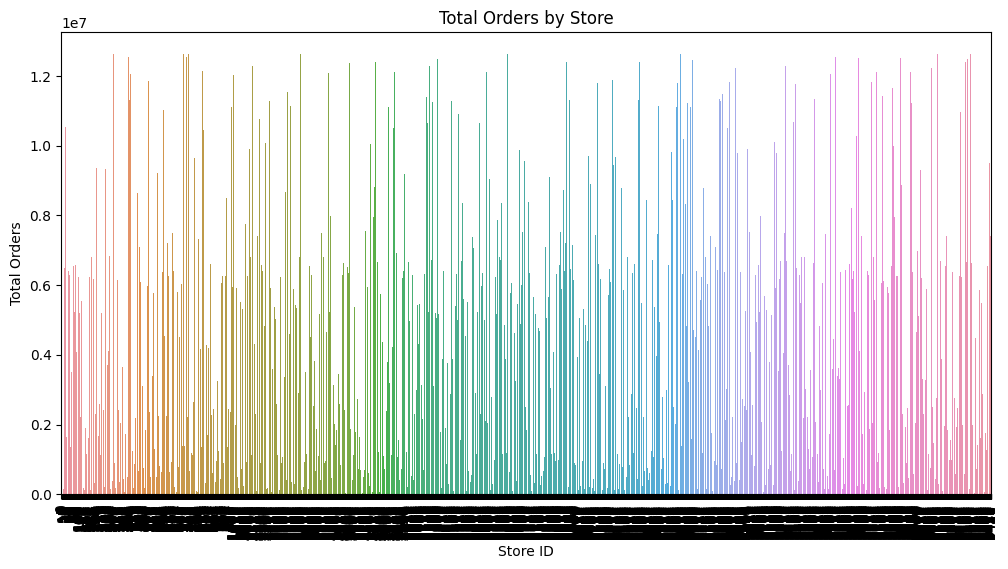

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(x=data['unique_id'], y=data['total_orders'], estimator=sum, ci=None)
plt.xticks(rotation=90)
plt.title("Total Orders by Store")
plt.xlabel("Store ID")
plt.ylabel("Total Orders")
plt.show()


Merging all the other datas with the main sales_train

In [21]:
calendar

,date,holiday_name,holiday,shops_closed,winter_school_holidays,school_holidays,warehouse
0,2022-03-16,NaN,0,0,0,0,Frankfurt_1
1,2020-03-22,NaN,0,0,0,0,Frankfurt_1
2,2018-02-07,NaN,0,0,0,0,Frankfurt_1
3,2018-08-10,NaN,0,0,0,0,Frankfurt_1
4,2017-10-26,NaN,0,0,0,0,Prague_2
...,...,...,...,...,...,...,...
23011,2019-04-20,NaN,1,0,0,0,Munich_1
23012,2018-03-31,NaN,1,0,0,0,Munich_1
23013,2017-04-15,NaN,1,0,0,0,Munich_1
23014,2023-04-08,NaN,1,0,0,1,Munich_1


In [22]:
inventory

,unique_id,product_unique_id,name,L1_category_name_en,L2_category_name_en,L3_category_name_en,L4_category_name_en,warehouse
0,5255,2583,Pastry_196,Bakery,Bakery_L2_14,Bakery_L3_26,Bakery_L4_1,Prague_3
1,4948,2426,Herb_19,Fruit and vegetable,Fruit and vegetable_L2_30,Fruit and vegetable_L3_86,Fruit and vegetable_L4_1,Prague_3
2,2146,1079,Beet_2,Fruit and vegetable,Fruit and vegetable_L2_3,Fruit and vegetable_L3_65,Fruit and vegetable_L4_34,Prague_1
3,501,260,Chicken_13,Meat and fish,Meat and fish_L2_13,Meat and fish_L3_27,Meat and fish_L4_5,Prague_1
4,4461,2197,Chicory_1,Fruit and vegetable,Fruit and vegetable_L2_17,Fruit and vegetable_L3_33,Fruit and vegetable_L4_1,Frankfurt_1
...,...,...,...,...,...,...,...,...
5427,3772,1849,Bread_147,Bakery,Bakery_L2_9,Bakery_L3_146,Bakery_L4_1,Budapest_1
5428,5191,2555,Pastry_195,Bakery,Bakery_L2_14,Bakery_L3_26,Bakery_L4_1,Prague_2
5429,5226,2570,Pumpkin_22,Fruit and vegetable,Fruit and vegetable_L2_3,Fruit and vegetable_L3_99,Fruit and vegetable_L4_1,Prague_3
5430,5390,2649,Orange_32,Fruit and vegetable,Fruit and vegetable_L2_0,Fruit and vegetable_L3_46,Fruit and vegetable_L4_13,Budapest_1


In [23]:
data

,unique_id,date,warehouse,total_orders,sales,sell_price_main,availability,type_0_discount,type_1_discount,type_2_discount,type_3_discount,type_4_discount,type_5_discount,type_6_discount
0,4845,2024-03-10,Budapest_1,6436.0,1.929869,646.26,1.00,0.00000,0.0,0.0,0.0,0.15312,0.0,0.0
1,4845,2021-05-25,Budapest_1,4663.0,1.929869,455.96,1.00,0.00000,0.0,0.0,0.0,0.15025,0.0,0.0
2,4845,2021-12-20,Budapest_1,6507.0,1.929869,455.96,1.00,0.00000,0.0,0.0,0.0,0.15025,0.0,0.0
3,4845,2023-04-29,Budapest_1,5463.0,1.929869,646.26,0.96,0.20024,0.0,0.0,0.0,0.15312,0.0,0.0
4,4845,2022-04-01,Budapest_1,5997.0,1.929869,486.41,1.00,0.00000,0.0,0.0,0.0,0.15649,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4007414,4941,2023-06-21,Prague_1,9988.0,1.929869,34.06,1.00,0.00000,0.0,0.0,0.0,0.00000,0.0,0.0
4007415,4941,2023-06-24,Prague_1,8518.0,1.929869,34.06,1.00,0.00000,0.0,0.0,0.0,0.00000,0.0,0.0
4007416,4941,2023-06-23,Prague_1,10424.0,1.929869,34.06,1.00,0.00000,0.0,0.0,0.0,0.00000,0.0,0.0
4007417,4941,2023-06-22,Prague_1,10342.0,1.929869,34.06,1.00,0.00000,0.0,0.0,0.0,0.00000,0.0,0.0


In [24]:
data = data.merge(inventory[['unique_id', 'product_unique_id', 'name', 
                                'L1_category_name_en', 'L2_category_name_en', 
                                'L3_category_name_en', 'L4_category_name_en']], 
                on='unique_id', how='left')

In [25]:
data = data.merge(calendar[['date', 'warehouse', 'holiday', 'holiday_name', 
                                'shops_closed', 'winter_school_holidays', 'school_holidays']], 
                on=['date', 'warehouse'], how='left')


In [26]:
data

,unique_id,date,warehouse,total_orders,sales,sell_price_main,availability,type_0_discount,type_1_discount,type_2_discount,...,name,L1_category_name_en,L2_category_name_en,L3_category_name_en,L4_category_name_en,holiday,holiday_name,shops_closed,winter_school_holidays,school_holidays
0,4845,2024-03-10,Budapest_1,6436.0,1.929869,646.26,1.00,0.00000,0.0,0.0,...,Croissant_35,Bakery,Bakery_L2_18,Bakery_L3_83,Bakery_L4_1,0,NaN,0,0,0
1,4845,2021-05-25,Budapest_1,4663.0,1.929869,455.96,1.00,0.00000,0.0,0.0,...,Croissant_35,Bakery,Bakery_L2_18,Bakery_L3_83,Bakery_L4_1,0,NaN,0,0,0
2,4845,2021-12-20,Budapest_1,6507.0,1.929869,455.96,1.00,0.00000,0.0,0.0,...,Croissant_35,Bakery,Bakery_L2_18,Bakery_L3_83,Bakery_L4_1,0,NaN,0,0,0
3,4845,2023-04-29,Budapest_1,5463.0,1.929869,646.26,0.96,0.20024,0.0,0.0,...,Croissant_35,Bakery,Bakery_L2_18,Bakery_L3_83,Bakery_L4_1,0,NaN,0,0,0
4,4845,2022-04-01,Budapest_1,5997.0,1.929869,486.41,1.00,0.00000,0.0,0.0,...,Croissant_35,Bakery,Bakery_L2_18,Bakery_L3_83,Bakery_L4_1,0,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4007414,4941,2023-06-21,Prague_1,9988.0,1.929869,34.06,1.00,0.00000,0.0,0.0,...,Kohlrabi_9,Fruit and vegetable,Fruit and vegetable_L2_3,Fruit and vegetable_L3_114,Fruit and vegetable_L4_1,0,NaN,0,0,0
4007415,4941,2023-06-24,Prague_1,8518.0,1.929869,34.06,1.00,0.00000,0.0,0.0,...,Kohlrabi_9,Fruit and vegetable,Fruit and vegetable_L2_3,Fruit and vegetable_L3_114,Fruit and vegetable_L4_1,0,NaN,0,0,0
4007416,4941,2023-06-23,Prague_1,10424.0,1.929869,34.06,1.00,0.00000,0.0,0.0,...,Kohlrabi_9,Fruit and vegetable,Fruit and vegetable_L2_3,Fruit and vegetable_L3_114,Fruit and vegetable_L4_1,0,NaN,0,0,0
4007417,4941,2023-06-22,Prague_1,10342.0,1.929869,34.06,1.00,0.00000,0.0,0.0,...,Kohlrabi_9,Fruit and vegetable,Fruit and vegetable_L2_3,Fruit and vegetable_L3_114,Fruit and vegetable_L4_1,0,NaN,0,0,0


In [27]:
data.isnull().sum()

unique_id                       0
date                            0
warehouse                       0
total_orders                   52
sales                           0
sell_price_main                 0
availability                    0
type_0_discount                 0
type_1_discount                 0
type_2_discount                 0
type_3_discount                 0
type_4_discount                 0
type_5_discount                 0
type_6_discount                 0
product_unique_id               0
name                            0
L1_category_name_en             0
L2_category_name_en             0
L3_category_name_en             0
L4_category_name_en             0
holiday                         0
holiday_name              3844119
shops_closed                    0
winter_school_holidays          0
school_holidays                 0
dtype: int64

In [28]:
data = data.merge(test_weight[['unique_id','weight']],on='unique_id', how='left')

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4007419 entries, 0 to 4007418
Data columns (total 26 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   unique_id               int64  
 1   date                    object 
 2   warehouse               object 
 3   total_orders            float64
 4   sales                   float64
 5   sell_price_main         float64
 6   availability            float64
 7   type_0_discount         float64
 8   type_1_discount         float64
 9   type_2_discount         float64
 10  type_3_discount         float64
 11  type_4_discount         float64
 12  type_5_discount         float64
 13  type_6_discount         float64
 14  product_unique_id       int64  
 15  name                    object 
 16  L1_category_name_en     object 
 17  L2_category_name_en     object 
 18  L3_category_name_en     object 
 19  L4_category_name_en     object 
 20  holiday                 int64  
 21  holiday_name            object 

In [32]:
"data.to_csv('Final_Raw_data/Final_data.csv',index=True)"